In [4]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob
from ase.io import read, write
from ase.build import make_supercell
import numpy as np

In [ ]:
def process_file(filename):
    try:
        with open(filename, "r") as f:
            lines = f.readlines()[4:-1]

        theta_data, phior_data = [], []
        for line in lines:
            values = line.split()
            if len(values) >= 13:
                try:
                    t = float(values[8])
                    p = float(values[9])
                    if np.isnan(t) or np.isnan(p):
                        continue
                    theta_data.append(t)
                    phior_data.append(p)
                except ValueError:
                    continue

        if not theta_data:
            print(f"⚠ Cap dada vàlida a {filename}, saltant...")
            return

        theta_data = np.array(theta_data)
        phior_data = np.array(phior_data)

        fig, ax = plt.subplots(figsize=(6, 5))
        h = ax.hist2d(theta_data, phior_data, bins=100, cmap='Blues', alpha=0.75)
        ax.set_title("Histograma 2D")
        ax.set_xlabel(r'$\cos(\theta)$')
        ax.set_ylabel(r'$\phi$ (graus)')
        #ax.set_xlim(-1, 1)
        #ax.set_ylim(-180, 180)
        fig.colorbar(h[3], ax=ax, label='Densitat')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"⚠ Fitxer {filename} no trobat, saltant...")

#filenames = sorted(glob.glob("/Users/aressanuylatorre/Desktop/doc/penta/files/ang_400_*.dat"))
filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_550_*.dat"))
if not filenames:
    print("⚠ Cap fitxer trobat amb aquest patró")
else:
    for filename in filenames:
        print(f"Processant {filename}...")
        process_file(filename)

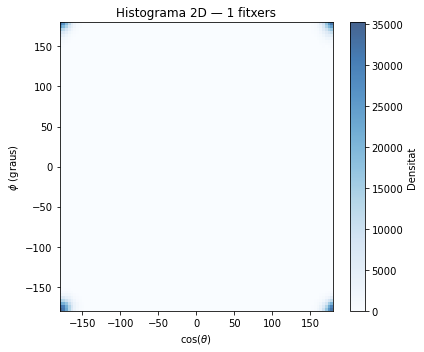

In [ ]:
def process_files_combined(filenames):
    theta_all, phi_all = [], []

    for filename in filenames:
        try:
            with open(filename, "r") as f:
                lines = f.readlines()[4:-1]

            for line in lines:
                values = line.split()
                if len(values) >= 13:
                    try:
                        t = float(values[6])
                        p = float(values[7])
                        if np.isnan(t) or np.isnan(p):
                            continue
                        theta_all.append(t)
                        phi_all.append(p)
                    except ValueError:
                        continue

        except FileNotFoundError:
            print(f"⚠ Fitxer {filename} no trobat, saltant...")

    if not theta_all:
        print("⚠ Cap dada vàlida, saltant...")
        return

    theta_all = np.array(theta_all)
    phi_all   = np.array(phi_all)

    fig, ax = plt.subplots(figsize=(6, 5))
    h = ax.hist2d(theta_all, phi_all, bins=100, cmap='Blues', alpha=0.75)
    ax.set_title(f"Histograma 2D — {len(filenames)} fitxers")
    ax.set_xlabel(r'$\cos(\theta)$')
    ax.set_ylabel(r'$\phi$ (graus)')
    #ax.set_xlim(-180, 180)
    #ax.set_ylim(-180, 180)
    fig.colorbar(h[3], ax=ax, label='Densitat')
    plt.tight_layout()
    plt.show()

#filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_550_*.dat"))
#filenames3 = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_400_*_pdespres.dat"))
filenames = sorted(glob.glob("/Users/aressanuylatorre/Desktop/doc/penta/files/ang_ori_475_1.dat"))
#filenames2 = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_550_*.dat"))
#filenames = sorted(glob.glob("/Users/aressanuylatorre/Desktop/doc/penta/files/ang_400_tot.dat"))

process_files_combined(filenames)

# Entropia

In [28]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

mac = Path("/Users/aressanuylatorre/")

if (mac / "Desktop/doc/NPG").exists():
    BASE = str(mac / "Desktop/doc/penta/files")
    NOU  = f"{BASE}"
    print(f"BASE: MAC")
else:
    BASE = "/home/aressanuy/Desktop/doc/pentaeritritol"
    NOU  = f"{BASE}/P0/angula"
    print(f"BASE: UPC")

# ==================================================
# PARELLES (T_abans, T_despres, P)
# ==================================================
parelles = {
    1:    (475, 480),
    1000: (375, 380),
    2000: (390, 395),
    3000: (395, 400),
    4000: (410, 415),
    5000: (415, 420),
}

def nou_abans(P):
    t_abans, _ = parelles[P]
    return f"{NOU}/ang_ori_{t_abans}_{P}.dat"
def nou_despres(P):
    _, t_despres = parelles[P]
    return f"{NOU}/ang_ori_{t_despres}_{P}.dat"

BASE: MAC


In [29]:
# =========================
# CONSTANTS I CODIS
# =========================
k      = 1.380649e-23
mmol   = 0.120147       # kg/mol
nmol   = 512
NA     = 6.02214076e23
massa  = mmol/ NA   # kg (massa molecula del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (theta, phi)."""
    with open(fname, "r") as f:
        lines = f.readlines()[4:-1]

    theta_data, phior_data = [], []
    for line in lines:
        values = line.split()
        if len(values) >= 13:
            try:
                t = float(values[6])
                p = float(values[7])
                if np.isnan(t) or np.isnan(p):
                    continue
                theta_data.append(t)
                phior_data.append(p)
            except ValueError:
                continue

    if not theta_data:
        print(f"⚠ Cap dada vàlida a {fname}, saltant...")
        return

    theta_data = np.array(theta_data)
    phior_data = np.array(phior_data)

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(theta_data, phior_data, bins=[edges, edges], density=True)

    Ap = 360 / bins
    p = hist * Ap * Ap
    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)

    return S / massa, p

def entropy_ori(fname, bins=100):
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                t = float(cols[8])
                p_ = float(cols[9])
                ps = float(cols[10])
                if any(np.isnan(x) for x in (t, p_, ps)):
                    continue
                th.append(t)
                phi.append(p_)
                psi.append(ps)
            except (IndexError, ValueError):
                continue
    intervals = [
        np.linspace(-1, 1, bins + 1),      # bins+1 edges → bins intervals
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    hist, edges = np.histogramdd((th, phi, psi), bins=intervals)

    # Normalitzar explícitament → p suma 1 sempre
    p = hist / hist.sum()

    # Àrea del bin per la correcció d'entropia
    dth  = edges[0][1]  - edges[0][0]
    dphi = edges[1][1]  - edges[1][0]
    dpsi = edges[2][1]  - edges[2][0]
    A = dth * dphi * dpsi

    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
    return S / massa, p
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)
    Sthpsi  = S_2d(th, psi, 8, 10)
    Sphipsi = S_2d(phi, psi, 9, 10)
    Sth     = S_1d(th,  8)
    Sphi    = S_1d(phi, 9)
    Spsi    = S_1d(psi, 10)

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    return Stot / massa , p

P=    1 bar  K Sc1=498.9387393234001 Sc2=700.2026493194552 Sc=201.26390999605508 So1=613.7319650435267 So2=853.9349361168771 So=240.20297107335045  St=441.46688106940553  J/(kg·K)
P=    1 bar  K  Sc=201.26390999605508  So=240.20297107335045  St=441.46688106940553  J/(kg·K)


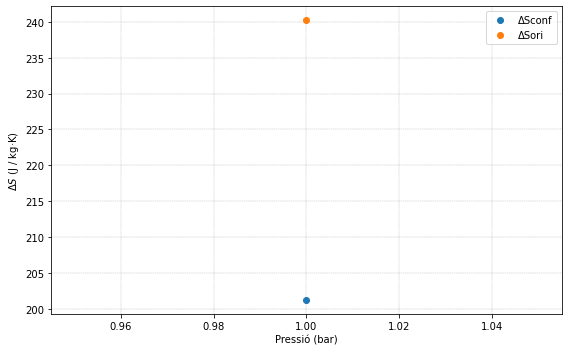

In [30]:
resultats = []

parelles2 = [1]

for P in parelles2:
    Sc = -entropy_conf(nou_abans(P), bins=200)[0] + entropy_conf(nou_despres(P), bins=200)[0]
    Sc1 = entropy_conf(nou_abans(P), bins=200)[0]
    Sc2 = entropy_conf(nou_despres(P), bins=200)[0]
    So = -entropy_ori(nou_abans(P), bins=20)[0] + entropy_ori(nou_despres(P), bins=20)[0]
    So1 = entropy_ori(nou_abans(P), bins=20)[0]
    So2 = entropy_ori(nou_despres(P), bins=20)[0]
    St = Sc + So

    resultats.append((P, Sc, So, St))
    print(f"P={P:5d} bar  K Sc1={Sc1} Sc2={Sc2} Sc={Sc} So1={So1} So2={So2} So={So}  St={St}  J/(kg·K)")
    print(f"P={P:5d} bar  K  Sc={Sc}  So={So}  St={St}  J/(kg·K)")

# Plot
pressions = [r[0] for r in resultats]
Sc_list   = [r[1] for r in resultats]
So_list   = [r[2] for r in resultats]
St_list   = [r[3] for r in resultats]

plt.figure(figsize=(8,5))
plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
plt.plot(pressions, So_list, 'o', label='ΔSori')
#plt.plot(pressions, St_list, 'o', label='ΔStotal')
plt.xlabel('Pressió (bar)')
plt.ylabel(r'$\Delta S$ (J / kg·K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

N punts: 1228800


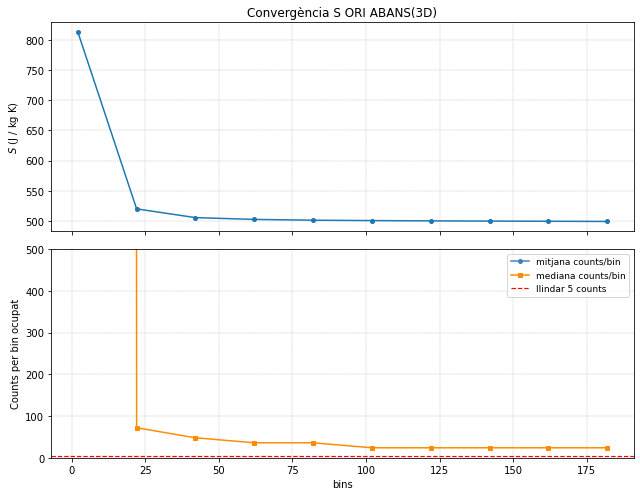

N punts: 1228800


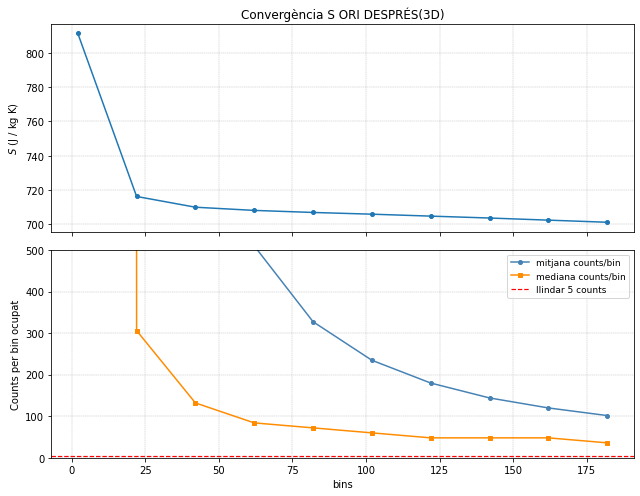

In [25]:

def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    print(f"N punts: {len(th)}")
    return len(th)
def diagnose_histogram_counts(fname, bins, entropy_fn=entropy_ori, label=""):
    S, p = entropy_fn(fname, bins=bins)
    
    # Reconstruir counts (p normalitzada → multipliquem per N)
    N = count_points(fname)
    counts = p * N  # counts aproximats per bin
    
    ocupats = counts[counts > 0]
    
    mean_counts  = ocupats.mean()
    median_counts = np.median(ocupats)
    below_thresh  = np.sum(ocupats < 7)
    pct_below     = 100 * below_thresh / len(ocupats)
    return mean_counts, median_counts

def convergence_plot_counts(fname, bins_list, entropy_fn=entropy_ori, 
                             threshold=7, label=""):
    N = count_points(fname)
    S_list, mean_list, median_list, pct_below_list = [], [], [], []

    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        counts = p * N

        ocupats = counts[counts > 0]
        mean_c   = ocupats.mean()
        median_c = np.median(ocupats)
        pct_below = 100 * np.sum(ocupats < threshold) / len(ocupats)

        S_list.append(S)
        mean_list.append(mean_c)
        median_list.append(median_c)
        pct_below_list.append(pct_below)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)
    #ax1.set_ylim(0, 500)

    ax2.plot(bins_list, mean_list,   '-o', ms=4, color='steelblue',  label='mitjana counts/bin')
    ax2.plot(bins_list, median_list, '-s', ms=4, color='darkorange', label='mediana counts/bin')
    ax2.axhline(threshold, color='red', lw=1.2, ls='--', 
                label=f'llindar {threshold} counts')
    ax2.set_ylabel('Counts per bin ocupat')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)
    ax2.set_ylim(0, 500)


    plt.tight_layout()
    plt.show()

    return (np.array(S_list), np.array(mean_list), 
            np.array(median_list), np.array(pct_below_list))

# Per conf (2D) — rang gran
S_conf, occ_conf, *_ = convergence_plot_counts(
    nou_abans(1), bins_list=np.arange(2, 200, 20),
    entropy_fn=entropy_conf,
    threshold=5,
    label="Convergència S ORI ABANS(3D)"
)

S_conf, occ_conf, *_ = convergence_plot_counts(
    nou_despres(1), bins_list=np.arange(2, 200, 20),
    entropy_fn=entropy_conf,
    threshold=5,
    label="Convergència S ORI DESPRÉS(3D)"
)

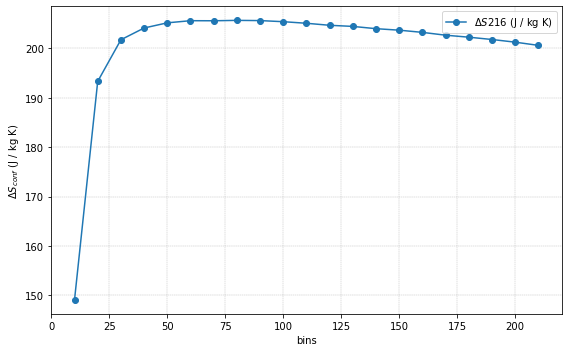

(699.4259067770332, 498.8084491147074)

In [27]:

def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216 = []
    llS512a,llS512b = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]   
        S216.append(S216a - S216b)

    S216 = np.array(S216)

    plt.figure(figsize=(8, 5))
    #plt.plot(bins_list, llS512a, '-o', label='300')
    plt.plot(bins_list, S216, '-o', label=r'$\Delta S 216$ (J / kg K)')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216a, S216b


bins_list = np.arange(10, 220, 10)

P = 1
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)


# Amb entropy_conf 
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, entropy_fn=entropy_conf, ylabel=r'$\Delta S_{conf}$ (J / kg K)')